In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('songs.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8076 entries, 0 to 8075
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        8076 non-null   int64  
 1   artist_name       8076 non-null   object 
 2   track_name        8076 non-null   object 
 3   track_id          8076 non-null   object 
 4   popularity        8076 non-null   int64  
 5   year              8076 non-null   int64  
 6   genre             8076 non-null   object 
 7   danceability      8076 non-null   float64
 8   energy            8076 non-null   float64
 9   key               8076 non-null   int64  
 10  loudness          8076 non-null   float64
 11  mode              8076 non-null   int64  
 12  speechiness       8076 non-null   float64
 13  acousticness      8076 non-null   float64
 14  instrumentalness  8076 non-null   float64
 15  liveness          8076 non-null   float64
 16  valence           8076 non-null   float64


In [5]:
df.describe(include="all")

,Unnamed: 0,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,hit
count,8076.00000,8076,8076,8076,8076.000000,8076.000000,8076,8076.000000,8076.000000,8076.000000,...,8076.000000,8076.000000,8076.000000,8076.000000,8076.000000,8076.000000,8076.000000,8.076000e+03,8076.000000,8076
unique,NaN,4393,7678,8076,NaN,NaN,82,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Drake,Home,5qdQPrWmZv8xYhMJCDrdHF,NaN,NaN,country,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
freq,NaN,102,7,1,NaN,NaN,1137,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4038
mean,4037.50000,NaN,NaN,NaN,36.137444,2012.233531,NaN,0.577967,0.662110,5.303739,...,0.655894,0.089605,0.249717,0.126749,0.198351,0.479233,121.802049,2.359567e+05,3.922239,NaN
std,2331.48472,NaN,NaN,NaN,24.178125,7.007997,NaN,0.168533,0.229067,3.530634,...,0.475105,0.108770,0.304056,0.286240,0.167295,0.246251,29.496069,9.456595e+04,0.393943,NaN
min,0.00000,NaN,NaN,NaN,0.000000,2000.000000,NaN,0.000000,0.000039,0.000000,...,0.000000,0.000000,0.000001,0.000000,0.014400,0.000000,0.000000,1.749000e+04,0.000000,NaN
25%,2018.75000,NaN,NaN,NaN,14.000000,2006.000000,NaN,0.474000,0.518750,2.000000,...,0.000000,0.035200,0.013400,0.000000,0.096800,0.282750,98.212250,1.905052e+05,4.000000,NaN
50%,4037.50000,NaN,NaN,NaN,36.000000,2013.000000,NaN,0.586000,0.703000,5.000000,...,1.000000,0.048900,0.099600,0.000008,0.129000,0.472000,121.532500,2.216865e+05,4.000000,NaN
75%,6056.25000,NaN,NaN,NaN,57.000000,2018.000000,NaN,0.697000,0.845000,8.000000,...,1.000000,0.089000,0.409000,0.006902,0.261000,0.674000,140.030500,2.608165e+05,4.000000,NaN


The following columns are deemed not important features in the prediction of a hit track

In [6]:
selected_columns = ['Unnamed: 0', 'artist_name', 'track_name', 'track_id', 'popularity', 'year']
df.drop(columns=selected_columns, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8076 entries, 0 to 8075
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genre             8076 non-null   object 
 1   danceability      8076 non-null   float64
 2   energy            8076 non-null   float64
 3   key               8076 non-null   int64  
 4   loudness          8076 non-null   float64
 5   mode              8076 non-null   int64  
 6   speechiness       8076 non-null   float64
 7   acousticness      8076 non-null   float64
 8   instrumentalness  8076 non-null   float64
 9   liveness          8076 non-null   float64
 10  valence           8076 non-null   float64
 11  tempo             8076 non-null   float64
 12  duration_ms       8076 non-null   int64  
 13  time_signature    8076 non-null   int64  
 14  hit               8076 non-null   bool   
dtypes: bool(1), float64(9), int64(4), object(1)
memory usage: 891.3+ KB


In [8]:
df['genre'].unique()

array(['country', 'hip-hop', 'soul', 'spanish', 'alt-rock', 'punk',
       'hardstyle', 'romance', 'sertanejo', 'hardcore', 'electronic',
       'piano', 'acoustic', 'forro', 'gospel', 'chicago-house', 'edm',
       'cantopop', 'ska', 'k-pop', 'emo', 'industrial', 'heavy-metal',
       'singer-songwriter', 'club', 'french', 'pop', 'folk', 'psych-rock',
       'dance', 'salsa', 'opera', 'classical', 'minimal-techno', 'garage',
       'dancehall', 'drum-and-bass', 'power-pop', 'new-age', 'swedish',
       'electro', 'deep-house', 'pop-film', 'techno', 'rock',
       'progressive-house', 'metal', 'jazz', 'disco', 'guitar', 'ambient',
       'funk', 'sleep', 'indian', 'black-metal', 'blues', 'party',
       'comedy', 'show-tunes', 'grindcore', 'songwriter', 'groove',
       'trance', 'death-metal', 'rock-n-roll', 'german', 'house',
       'breakbeat', 'dubstep', 'samba', 'detroit-techno', 'punk-rock',
       'dub', 'afrobeat', 'goth', 'sad', 'trip-hop', 'hard-rock',
       'indie-pop', 'ch

In [ ]:
main_genres = ['country', 'hip-hop', 'pop', 'rock', 'jazz', 'electronic', 'gospel', 'classical', 'world music', 'acoustic']
country_subgenre = ['country']
hip_hop_subgenre = ['hip-hop', 'breakbeat']
pop_subgenre = ['pop', 'power-pop', 'indie-pop', 'pop-film']
rock_subgenre = ['alt-rock', 'punk', 'rock', 'hardcore', 'emo', 'heavy-metal', 'psych-rock', 'metal', 'black-metal', 'grindcore', 'rock-n-roll', 'death-metal', 'punk-rock', 'trip-hop', 'hard-rock', 'metalcore', 'guitar', 'goth']
jazz_subgenre = ['funk', 'romance', 'blues', 'jazz', 'soul']
electronic_subgenre = ['electronic', 'club', 'dance', 'minimal-techno', 'garage', 'electro', 'edm', 'deep-house', 'techno', 'disco', 'party', 'trance', 'groove', 'house', 'dubstep', 'detroit-techno', 'dub', 'chicago-house', 'drum-and-bass', 'progressive-house']
gospel_subgenre = ['gospel']
classical_subgenre = ['classical', 'opera']
acoustic_subgenre = ['acoustic', 'ambient', 'singer-songwriter', 'songwriter', 'chill']

In [12]:
def main_genre(subgenre):
    if subgenre in country_subgenre:
        return 'country'
    elif subgenre in hip_hop_subgenre:
        return 'hip-hop'
    elif subgenre in pop_subgenre:
        return 'pop'
    elif subgenre in rock_subgenre:
        return 'rock'
    elif subgenre in jazz_subgenre:
        return 'jazz'
    elif subgenre in electronic_subgenre:
        return 'electronic'
    elif subgenre in gospel_subgenre:
        return 'gospel'
    elif subgenre in classical_subgenre:
        return 'classical'
    elif subgenre in acoustic_subgenre:
        return 'acoustic'
    else:
        return 'world music'

In [13]:
df['main_genre'] = df['genre'].apply(main_genre)


In [14]:
df.head()

,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,hit,main_genre
0,country,0.621,0.791,9,-3.343,1,0.0265,0.0361,0.000000,0.1430,0.734,95.075,209110,4,True,country
1,hip-hop,0.788,0.765,2,-3.930,1,0.4390,0.2740,0.000000,0.2160,0.666,144.049,223617,4,True,hip-hop
2,hip-hop,0.863,0.705,8,-6.202,1,0.3100,0.0500,0.000022,0.5240,0.599,145.099,189013,4,True,hip-hop
3,soul,0.672,0.483,7,-6.700,0,0.0671,0.1510,0.000351,0.4850,0.907,72.011,221328,4,False,jazz
4,spanish,0.688,0.944,4,-5.408,0,0.3960,0.4050,0.000000,0.0685,0.714,93.789,129440,4,False,world music


In [36]:
df.drop(columns=['genre'], inplace=True)

/var/folders/_b/w92vsxlx1c3138gmh19pr9dr0000gn/T/ipykernel_28958/3754411100.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')


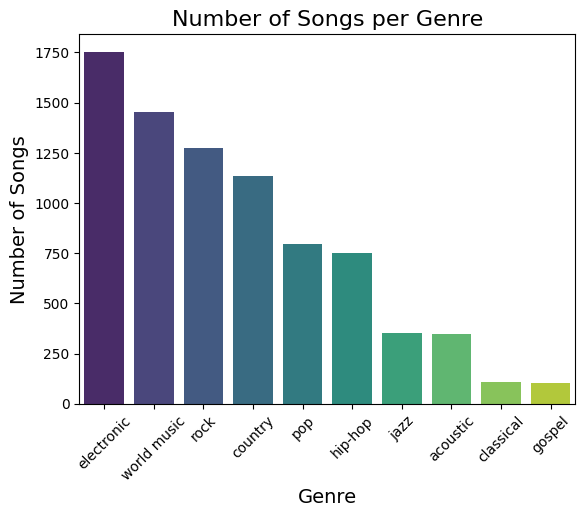

In [37]:
genre_counts = df['main_genre'].value_counts()

# Plot using seaborn
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
plt.title('Number of Songs per Genre', fontsize=16)
plt.xlabel('Genre', fontsize=14)
plt.ylabel('Number of Songs', fontsize=14)
plt.xticks(rotation=45)
plt.show()

/var/folders/_b/w92vsxlx1c3138gmh19pr9dr0000gn/T/ipykernel_28958/2227515101.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hit_songs_per_genre.index, y=hit_songs_per_genre.values, palette='magma')


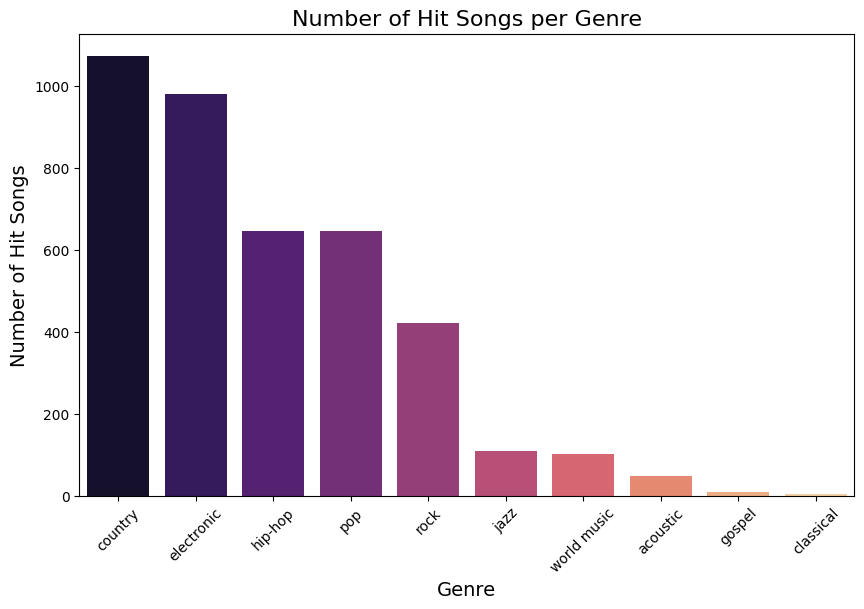

In [38]:
hit_songs_per_genre = df[df['hit'] == 1]['main_genre'].value_counts()

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=hit_songs_per_genre.index, y=hit_songs_per_genre.values, palette='magma')
plt.title('Number of Hit Songs per Genre', fontsize=16)
plt.xlabel('Genre', fontsize=14)
plt.ylabel('Number of Hit Songs', fontsize=14)
plt.xticks(rotation=45)
plt.show()

In [39]:
features = ['loudness', 'danceability', 'valence', 'energy']

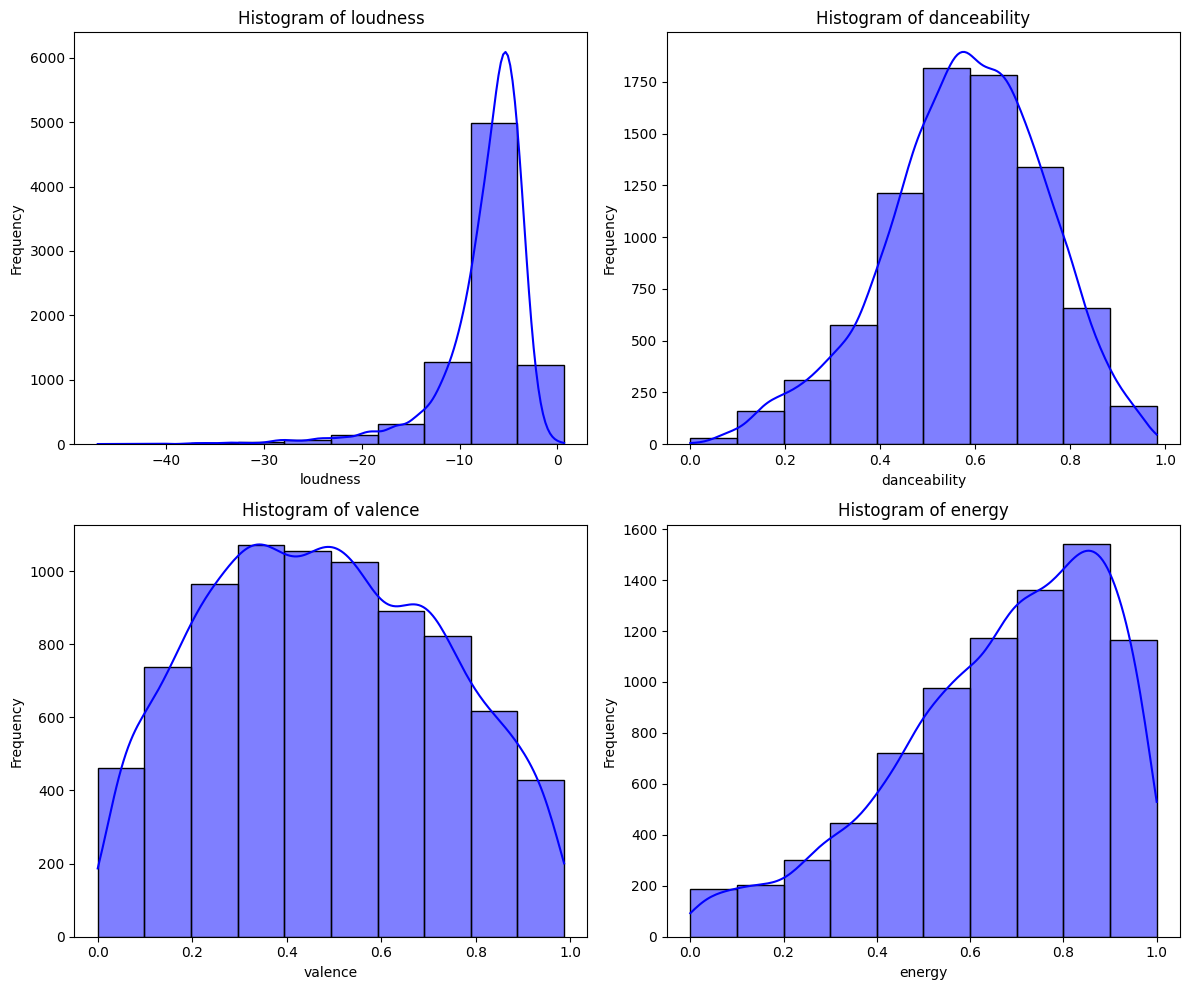

In [40]:
plt.figure(figsize=(12, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde=True, bins=10, color='blue')
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

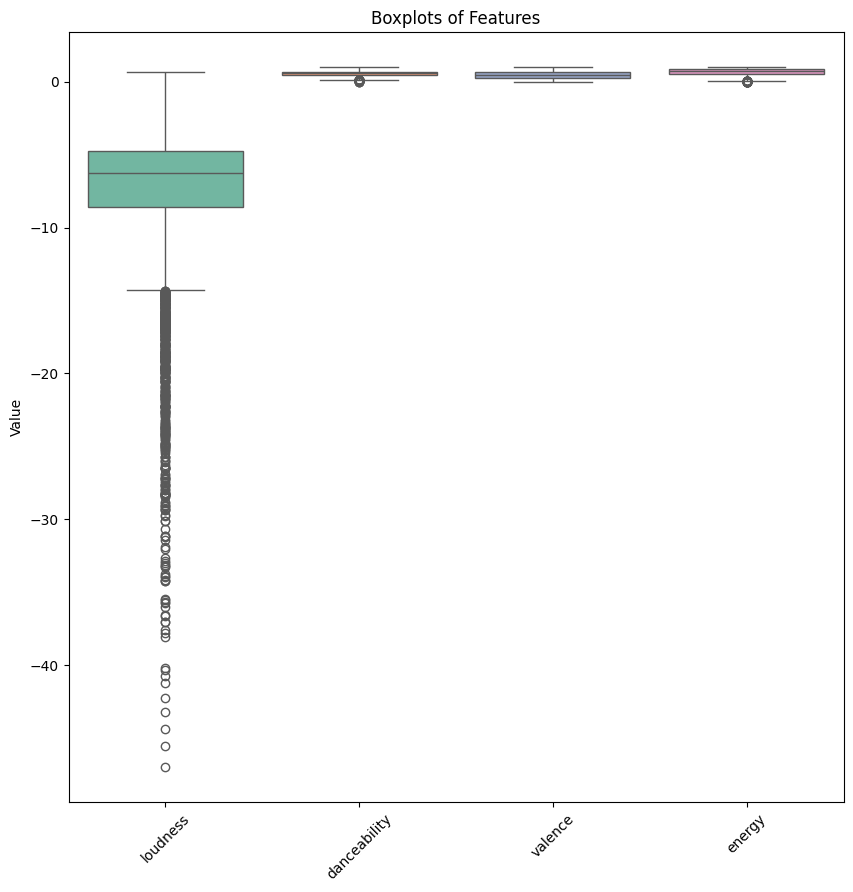

In [41]:
plt.figure(figsize=(10, 10))
sns.boxplot(data=df[features], palette='Set2')
plt.title('Boxplots of Features')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()

# MODELING

In [42]:
df.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,hit,main_genre
0,0.621,0.791,9,-3.343,1,0.0265,0.0361,0.000000,0.1430,0.734,95.075,209110,4,True,country
1,0.788,0.765,2,-3.930,1,0.4390,0.2740,0.000000,0.2160,0.666,144.049,223617,4,True,hip-hop
2,0.863,0.705,8,-6.202,1,0.3100,0.0500,0.000022,0.5240,0.599,145.099,189013,4,True,hip-hop
3,0.672,0.483,7,-6.700,0,0.0671,0.1510,0.000351,0.4850,0.907,72.011,221328,4,False,jazz
4,0.688,0.944,4,-5.408,0,0.3960,0.4050,0.000000,0.0685,0.714,93.789,129440,4,False,world music


In [43]:
X = df.drop('hit', axis=1)
y = df[['hit']]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
df.columns

Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'time_signature', 'hit', 'main_genre'],
      dtype='object')

In [122]:
cat_columns = ['main_genre']
num_columns = ['danceability', 'energy', 'loudness', 'mode', 'speechiness',
               'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
               'duration_ms', 'time_signature']
target = ['hit']

In [123]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [124]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns),  # Apply StandardScaler to numerical columns
        ('cat', OneHotEncoder(), cat_columns)   # Apply OneHotEncoder to categorical columns
    ]
)

In [125]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Logistic Regression

In [126]:
from sklearn.linear_model import LogisticRegression


In [127]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])
lr_pipeline.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['danceability', 'energy',
                                                   'loudness', 'mode',
                                                   'speechiness',
                                                   'acousticness',
                                                   'instrumentalness',
                                                   'liveness', 'valence',
                                                   'tempo', 'duration_ms',
                                                   'time_signature']),
                                                 ('cat', OneHotEncoder(),
                                                  ['main_genre'])])),
                ('classifier', LogisticRegression(random_state=42))])

In [128]:
y_pred = lr_pipeline.predict(X_test)
precision = precision_score(y_test, y_pred, pos_label= True)
recall = recall_score(y_test, y_pred, pos_label=True)
accuracy = accuracy_score(y_test, y_pred)
print(f'Precision Score: {precision}')
print(f'Recall Score: {recall}')
print(f'Accuracy: {accuracy}')

Precision Score: 0.8416856492027335
Recall Score: 0.9056372549019608
Accuracy: 0.8663366336633663


# 2. Random Forest

In [129]:
from sklearn.ensemble import RandomForestClassifier

In [130]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
rf_pipeline.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['danceability', 'energy',
                                                   'loudness', 'mode',
                                                   'speechiness',
                                                   'acousticness',
                                                   'instrumentalness',
                                                   'liveness', 'valence',
                                                   'tempo', 'duration_ms',
                                                   'time_signature']),
                                                 ('cat', OneHotEncoder(),
                                                  ['main_genre'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [131]:
y_pred = rf_pipeline.predict(X_test)
precision = precision_score(y_test, y_pred, pos_label= True)
recall = recall_score(y_test, y_pred, pos_label=True)
accuracy = accuracy_score(y_test, y_pred)
print(f'Precision Score: {precision}')
print(f'Recall Score: {recall}')
print(f'Accuracy: {accuracy}')

Precision Score: 0.8789659224441834
Recall Score: 0.9166666666666666
Accuracy: 0.8941831683168316


# 3. Adaboost

In [132]:
from sklearn.ensemble import AdaBoostClassifier

In [133]:
ada_boost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier())
])

ada_boost_pipeline.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['danceability', 'energy',
                                                   'loudness', 'mode',
                                                   'speechiness',
                                                   'acousticness',
                                                   'instrumentalness',
                                                   'liveness', 'valence',
                                                   'tempo', 'duration_ms',
                                                   'time_signature']),
                                                 ('cat', OneHotEncoder(),
                                                  ['main_genre'])])),
                ('classifier', AdaBoostClassifier())])

In [134]:
y_pred = ada_boost_pipeline.predict(X_test)
precision = precision_score(y_test, y_pred, pos_label= True)
recall = recall_score(y_test, y_pred, pos_label=True)
accuracy = accuracy_score(y_test, y_pred)
print(f'Precision Score: {precision}')
print(f'Recall Score: {recall}')
print(f'Accuracy: {accuracy}')

Precision Score: 0.8411428571428572
Recall Score: 0.9019607843137255
Accuracy: 0.864480198019802
